# i. Perkenalan

Nama: Muhammad Raifky Leditho

Batch: 036

### Latar Belakang:

Saya sedang bekerja sebagai admin sosial media di divisi sport yang di mana saya bekerja untuk membuat berita tentang berbagai macam olahraga. Ada hambatan di pekerjaan saya yaitu untuk memisah misahkan file yang berbentuk jpg yang berisi foto-foto olahraga yang nanti nya akan saya pakai untuk di posting sebagai berita. Maka dari itu saya ingin membuat model machine learning untuk memisahkan macam-macam foto olahraga untuk membantu pekerjaan sosial media memisahkan file-file tiap olahraga.

### Objective:

Membuat model machine learning untuk memprediksi olahraga berdasarkan gambar yang akan di kirim.



# ii. Import liblary

In [101]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import kagglehub
from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.optimizers import Adam


from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version
print(tf.__version__)

2.18.0


# iii. Data Loading

Importing dataset dari kaggle

In [68]:

# Download latest version
path = kagglehub.dataset_download("gpiosenka/sports-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Raifky\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9


Melihat file apa saja yang ada di dataset tersebut

In [ ]:
print(os.listdir(path)) #melihat isi dataset

['EfficientNetB0-100-(224 X 224)- 98.40.h5', 'sports.csv', 'test', 'train', 'valid']


Melihat file train

In [ ]:
os.listdir(os.path.join(path, 'train')) #melihat train set

['air hockey',
 'ampute football',
 'archery',
 'arm wrestling',
 'axe throwing',
 'balance beam',
 'barell racing',
 'baseball',
 'basketball',
 'baton twirling',
 'bike polo',
 'billiards',
 'bmx',
 'bobsled',
 'bowling',
 'boxing',
 'bull riding',
 'bungee jumping',
 'canoe slamon',
 'cheerleading',
 'chuckwagon racing',
 'cricket',
 'croquet',
 'curling',
 'disc golf',
 'fencing',
 'field hockey',
 'figure skating men',
 'figure skating pairs',
 'figure skating women',
 'fly fishing',
 'football',
 'formula 1 racing',
 'frisbee',
 'gaga',
 'giant slalom',
 'golf',
 'hammer throw',
 'hang gliding',
 'harness racing',
 'high jump',
 'hockey',
 'horse jumping',
 'horse racing',
 'horseshoe pitching',
 'hurdles',
 'hydroplane racing',
 'ice climbing',
 'ice yachting',
 'jai alai',
 'javelin',
 'jousting',
 'judo',
 'lacrosse',
 'log rolling',
 'luge',
 'motorcycle racing',
 'mushing',
 'nascar racing',
 'olympic wrestling',
 'parallel bar',
 'pole climbing',
 'pole dancing',
 'pole vau

Memilih 5 kelas dari file train

In [ ]:
selected_classes = [
    'basketball',
    'boxing',
    'baseball',
    'tennis',
    'judo'
] #memilih kelas


Insight:

Saya memilih 5 olahraga yaitu 2 olahraga combat boxing dan judo, olahraga lapangan baseball, tennis, dan 1 olahraga indoor yaitu basketball saya memilih olahraga tersebut agar model memiiki variasi gambar dan lighting dari foto yang berbeda beda.

In [ ]:
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=selected_classes  
)

valid_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'valid'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=selected_classes
)

test_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=selected_classes
)

Found 740 images belonging to 5 classes.
Found 25 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


# iv. EDA (Exploratory Data Analysist)

## iv.1 Distribusi dataset

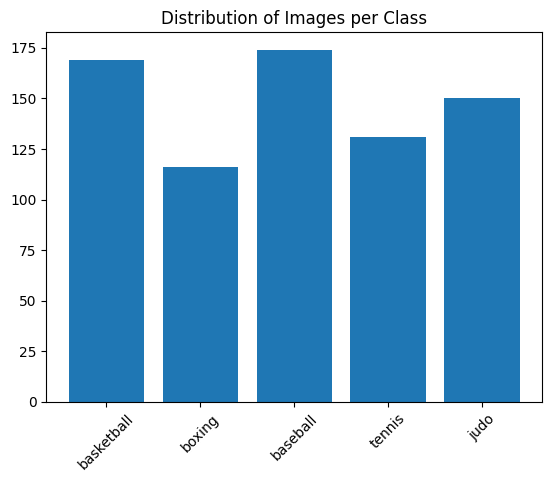

In [ ]:

train_path = os.path.join(path, 'train')

class_counts = {}
for cls in selected_classes:
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))# loop train images

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribution of Images per Class")
plt.show()


Insight:

Distribusi antar kelas relatif seimbang dengan jumlah gambar berkisar antara 115 hingga 170 per kelas. Meskipun kelas Boxing memiliki jumlah paling sedikit, perbedaannya tidak terlalu signifikan sehingga tidak diperlukan teknik penanganan imbalance khusus seperti class weighting.

## iv.2 Analisis ukuran gambar

In [ ]:
sizes = []
#loop untuk size image
for cls in selected_classes:
    for img_name in os.listdir(os.path.join(train_path, cls))[:50]:
        img_path = os.path.join(train_path, cls, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print(sizes[:10])

[(224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


Insight:

Dari dataset tersebut semua ukuran gambar adalah 224

## iv.3 Visualisasi sample gambar perkelas

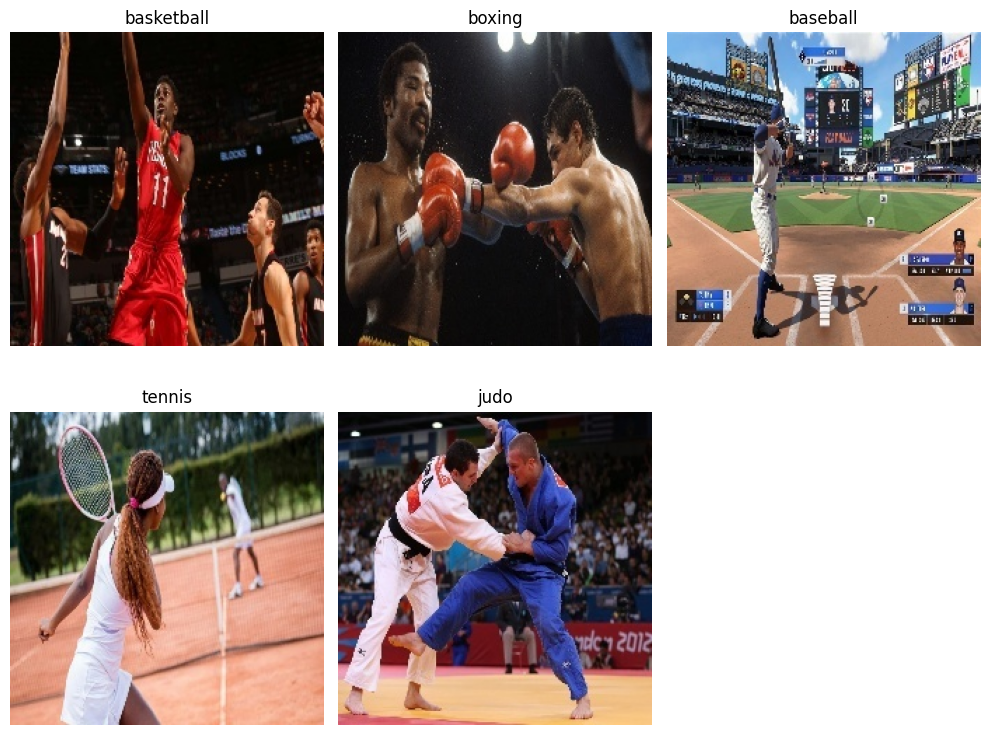

In [ ]:
plt.figure(figsize=(10,8))
#looping untuk melihat sample gambar
for i, cls in enumerate(selected_classes):
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img_path = os.path.join(train_path, cls, img_name)
    
    img = image.load_img(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Insight:

Berikut adalah sample gambar gambar dari dataset yang di temukan. terlihat resolusi dari gambar tersebut tidak begitu baik tetapi ini cukup untuk model untuk belajar gambar-gambar tersebut. Dan terlihat ada beberapa gambar tidak dari realife tetapi dari game olahraga.

# v. Feature Enginnering

## Image Resizing

Saya menggunakan resizing image menggunakan 224x224

In [ ]:
IMG_SIZE = (224, 224) #resize image 224
BATCH_SIZE = 32


## Data Augmentation

In [77]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)


In [78]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)


### Train

In [79]:
selected_classes = ['basketball', 'boxing', 'baseball', 'tennis', 'judo']

train_generator = train_datagen.flow_from_directory(
    path + '/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

val_generator = val_test_datagen.flow_from_directory(
    path + '/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

test_generator = val_test_datagen.flow_from_directory(
    path + '/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes,
    shuffle=False
)


Found 740 images belonging to 5 classes.
Found 25 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


## Encoding

In [84]:
{'basketball': 0,
 'baseball': 1,
 'boxing': 2,
 'judo': 3,
 'tennis': 4}


{'basketball': 0, 'baseball': 1, 'boxing': 2, 'judo': 3, 'tennis': 4}

In [85]:
print(train_generator.class_indices)


{'basketball': 0, 'boxing': 1, 'baseball': 2, 'tennis': 3, 'judo': 4}


# vi. ANN Training (Sequential API/Functional API)

## vi.1. Model Definition

Menggunakan model sequential dengan conv2D dan flatten

In [86]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

Compile

In [87]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## vi.2. Model Training

Melakukan model trainning sampai epochs 20

In [88]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 850ms/step - accuracy: 0.2652 - loss: 1.8096 - val_accuracy: 0.4000 - val_loss: 1.4033
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 578ms/step - accuracy: 0.3391 - loss: 1.4839 - val_accuracy: 0.4000 - val_loss: 1.3658
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 592ms/step - accuracy: 0.4153 - loss: 1.3807 - val_accuracy: 0.5200 - val_loss: 1.1055
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 586ms/step - accuracy: 0.4853 - loss: 1.2367 - val_accuracy: 0.6000 - val_loss: 1.0650
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 572ms/step - accuracy: 0.5287 - loss: 1.1240 - val_accuracy: 0.6800 - val_loss: 0.7876
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 600ms/step - accuracy: 0.5724 - loss: 1.0647 - val_accuracy: 0.8800 - val_loss: 0.6202
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 582ms/step - accuracy: 0.6284 - loss: 0.9824 - val_accuracy: 0.6800 - val_loss: 0.8006
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 593ms/step - accuracy: 0.6113 - loss: 1.0202 - val_accu

## vi.3. Model Evaluation

Melihat akurasi dari pada model ANN

In [89]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8000 - loss: 0.7108
Test Accuracy: 0.800000011920929


Melihat confusion matrix pada model ANN 

In [90]:
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
[[4 0 1 0 0]
 [0 5 0 0 0]
 [1 0 4 0 0]
 [0 1 1 3 0]
 [0 0 0 1 4]]


In [91]:
print(classification_report(y_true, y_pred, target_names=selected_classes))


              precision    recall  f1-score   support

  basketball       0.80      0.80      0.80         5
      boxing       0.83      1.00      0.91         5
    baseball       0.67      0.80      0.73         5
      tennis       0.75      0.60      0.67         5
        judo       1.00      0.80      0.89         5

    accuracy                           0.80        25
   macro avg       0.81      0.80      0.80        25
weighted avg       0.81      0.80      0.80        25



Insight:

Model mencapai akurasi 80% pada data pengujian. Performa terbaik terdapat pada kelas Boxing, sementara kelas Tennis dan Judo menunjukkan performa yang relatif lebih rendah. Hal ini kemungkinan disebabkan oleh kemiripan visual antar olahraga berbasis aktivitas manusia.

# vii. Model Definition (Improved)

## vii.1. Model Definition





Melakukan model improvement menggunakan transfer learning menggunakan MobileNetV2

In [102]:

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze pretrained weights

model_improved = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model_improved.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Berikut summart dari model improvement menggunakan mobilenetV2

In [ ]:
model_improved.summary() #summary model

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## vii.2. Model Training

Training model menggunakan EarlyStopping

In [104]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 572ms/step - accuracy: 0.2380 - loss: 1.9319 - val_accuracy: 0.4400 - val_loss: 1.3075
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 501ms/step - accuracy: 0.4026 - loss: 1.4072 - val_accuracy: 0.7600 - val_loss: 1.0373
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 497ms/step - accuracy: 0.5778 - loss: 1.1073 - val_accuracy: 0.8400 - val_loss: 0.8361
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 500ms/step - accuracy: 0.6230 - loss: 1.0188 - val_accuracy: 0.8800 - val_loss: 0.6870
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 498ms/step - accuracy: 0.6805 - loss: 0.8553 - val_accuracy: 0.8400 - val_loss: 0.5805
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 498ms/step - accuracy: 0.7663 - loss: 0.7291 - val_accuracy: 0.8400 - val_loss: 0.4786
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 517ms/step - accuracy: 0.7544 - loss: 0.6779 - val_accuracy: 0.8800 - val_loss: 0.4157
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 523ms/step - accuracy: 0.8022 - loss: 0.6251 - val_accu

Insight:

Training model sukses sampai epochs 20 dan tidak ada stop

## vii.3. Model Evaluation

Melihat akurasi setelah melakukan improvement model

In [105]:
test_loss, test_acc = model_improved.evaluate(test_generator)
print("Improved Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9600 - loss: 0.0897
Improved Test Accuracy: 0.9599999785423279


### Confusion Matrix

In [106]:
# Reset generator supaya mulai dari awal
test_generator.reset()

# Predict
predictions = model_improved.predict(test_generator)

# Ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(predictions, axis=1)

# Label asli
y_true = test_generator.classes

# Nama kelas
class_names = list(test_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


Melihat confusion matrix setelah improvment model

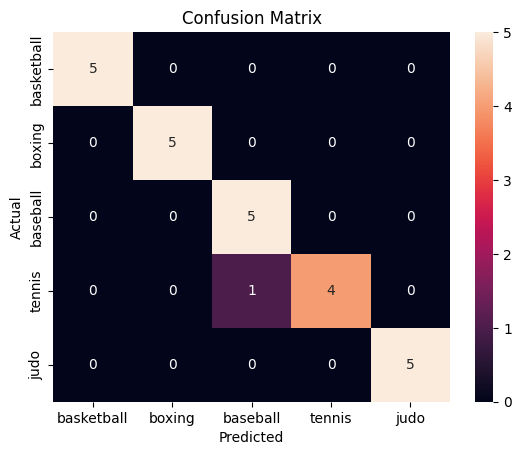

In [107]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Insight:

Semua olahraga terlihat memiliki nilai 5 kecuali tennis dan baseball. Ini di karenakan olahraga baseball dan olahraga tennnis memiliki gaya main yang mirip seperti memukul bola menggunakan tongkat untuk baseball, dan memukul bola menggunakan raket jadi model mungkin agak susah memprediksi kedua olahraga tersebut di karenakan hal tersebut.

In [108]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

  basketball       1.00      1.00      1.00         5
      boxing       1.00      1.00      1.00         5
    baseball       0.83      1.00      0.91         5
      tennis       1.00      0.80      0.89         5
        judo       1.00      1.00      1.00         5

    accuracy                           0.96        25
   macro avg       0.97      0.96      0.96        25
weighted avg       0.97      0.96      0.96        25



### Perbandingan Model awal dan model improved

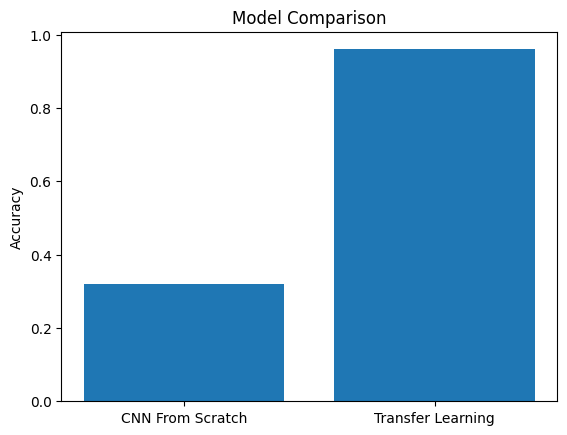

In [109]:
models = ['CNN From Scratch', 'Transfer Learning']
accuracy = [0.32, 0.96]

plt.figure()
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


Insight:

Dari model pertama atau CNN mendapatkan akurasi 0.3 yang di mana itu sangat kecil. Setelah melakukan improvement model menggunakan transfer learning yang di mana hasil dari transfer learning lebih baik di banding CNN, bisa di lihat dari bar chart di atas menunjukan transfer learning memiliki akurasi 0.95 yang di mana nilai nya lebih baik di banding CNN. Setelah melakukan improvement model di sini saya memilih transfer learning sebagai model yang akan di pakai pada saat inference.

# viii. Model Saving

In [110]:
model_improved.save("sports_classification_model.keras")

# ix. Inference Model

Hugging face link: https://huggingface.co/spaces/Raifky/sport_predict

# x. Kesimpulan

Model Analysist:

Setelah melakukan training model menggunakan 2 model yaitu CNN dan transfer learning menggunakan mobilenetV2. Terlihat kedua model memiliki kemampuan untuk prediksi yang sangat berbeda ANN memiliki akurasi 80% CNN 0.3 sedangkan model improvement menggunakan tranfer learning bisa memprediksi dengan akurasi samapi 0.95 atau 95%. Setelah melakukan training kepada kedua model di putuskan model yang akan di pakai untuk inference adalah model transfer learning menggunakan mobilenetV2 karena memiliki akurasi yang paling bagus maka dari itu saya akan menggunakan model tersebut untuk inference.

Overal analysist:

Model ini di buat untuk memprediksi olahraga berdasarkan gambar yang akan di kirim. Dengan menggunakan beberapa liblary seperti Matplotlib, seaborn untuk visualisasi data, numpy, tensor untuk melakukan training model dan membangun model ini. Setelah itu saya melakukan Exploratory data analysist untuk melihat distribusi dari dataset yang saya dapat, melihat dan menganalisa ukuran gambar dan melihat sample pada tiap gambar. Setelah melakukan EDA saya melakukan Feature Enginnering yang di antara nya image resizing, melakukan data augmentasi dan melakukan encoding untuk setiap kelas yang akan di pakai untuk inference. Setelah melakukan feature enginnering saya melakukan training model menggunakan ANN yang hasil akurasi dari model ANN adalah 80% dan training model menggunakan transfer learning menggunakan mobilenetV2 yang hasil akurasi nya lebih bagus di banding ANN yaitu 95% maka saya akan menggunakan transfer learing dengan mobilenetV2 untuk memprediksi foto olahraga. Setelah melakukan model training saya melakukan saving model dan setelah itu saya membuat file baru untuk inference model. Dan hasil dari inference model adalah model bisa memprediksi data baru dengan akurasi atau confidence level tidak terlalu tinggi hal ini di karenakan dataset test yang saya dapat sangat sedikit jadi model kurang variasi untuk belajar untuk memprediksi olahraga berdasarkan gambar.

Future Improvement:

Untuk future improvement untuk model ini adalah lebih memperbanyak train dan test images agar model lebih bagus tidak overfitting dan underfitting.

Kelebihan model:

Model sangat baik memprediksi olahraga basketball, boxing, dan lumayan untuk prediksiolahraga baseball dan tennis.

Kekurangan:

Model kurang baik memprediksi baseball dan tennis di karena kan olahraga yang mirip yaitu memukul bola dengan raket untuk tennis dan untuk
baseball memukul menggunakan stick baseball maka dari itu model ada kekurangan memprediksi olahraga tersebut dan tidak terlepas dari train 
dan test set yang sedikit. Dan model ini kurang bisa memprediksi olahraga judo mungkin di karenakan data image dari judo yang kurang dan seperti yang kita ketahui olahraga judo angle nya sangat ekstrem dan butuh banyak angle untuk mengetahui bahwa olahraga ini adalah judo jadi ini kekurangan dari model ini.